In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [7]:
exercise = pd.read_csv("exercise.csv")
calories = pd.read_csv("calories.csv")

In [8]:
exercise.head()


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [9]:
calories.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [10]:
data = exercise.merge(calories, on="User_ID")

In [11]:
data.head()


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [12]:
data.shape

(15000, 9)

In [13]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  str    
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), str(1)
memory usage: 1.0 MB


In [14]:
data.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [15]:
data=data.drop("User_ID",axis=1)

In [16]:
data.head()


,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [17]:
data["Gender"] = data["Gender"].map({
    "male": 0,
    "female": 1
})

In [18]:
data.head()


,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,1,27,154.0,58.0,10.0,81.0,39.8,35.0


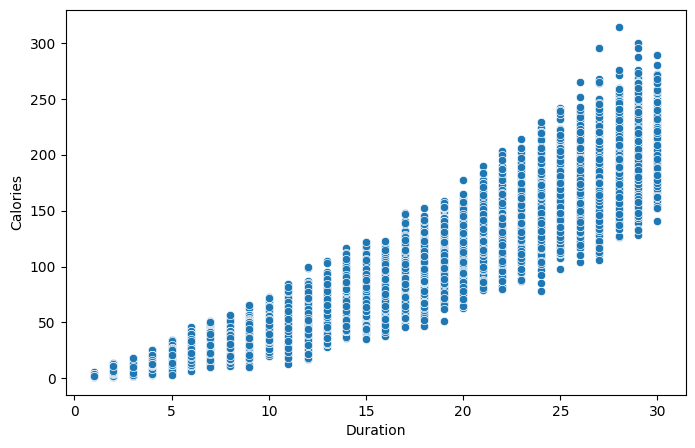

In [43]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=data["Duration"], y=data["Calories"])
plt.xlabel("Duration")
plt.ylabel("Calories")
plt.show()

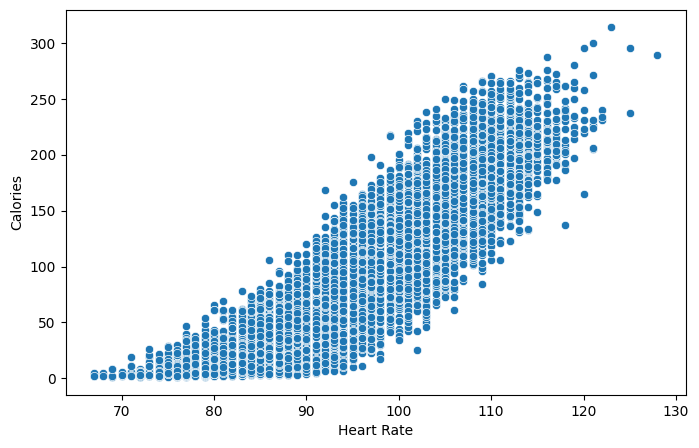

In [44]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=data["Heart_Rate"], y=data["Calories"])
plt.xlabel("Heart Rate")
plt.ylabel("Calories")
plt.show()

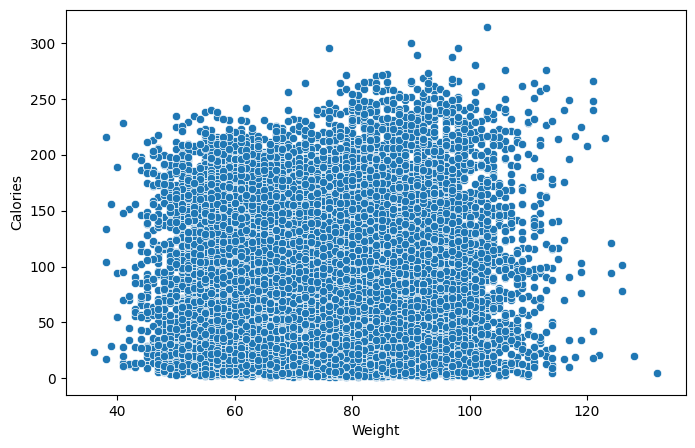

In [45]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=data["Weight"], y=data["Calories"])
plt.xlabel("Weight")
plt.ylabel("Calories")
plt.show()

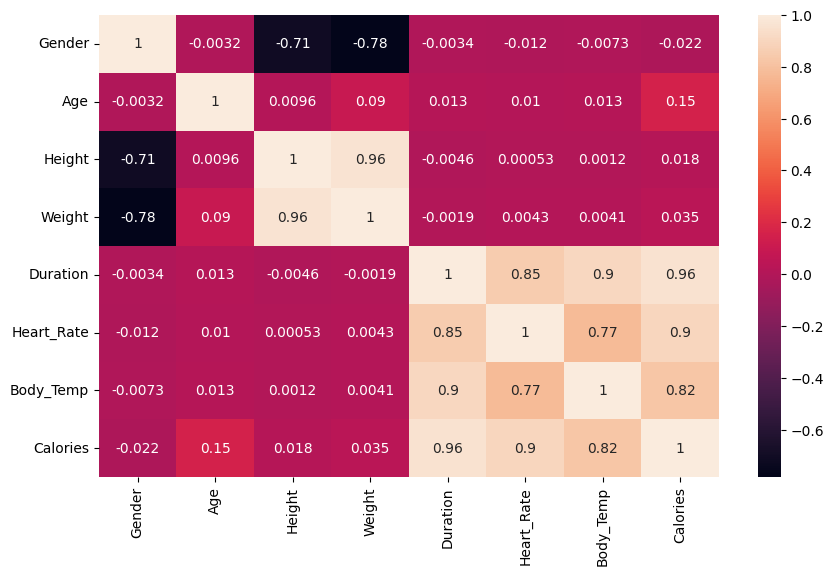

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(),annot=True)
plt.show()

In [20]:
X = data.drop("Calories", axis=1)
y = data["Calories"]

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
X_train.shape

(12000, 7)

In [24]:
X_test.shape

(3000, 7)

In [25]:
y_train.shape

(12000,)

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
Model=LinearRegression()

In [29]:
Model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
predictions=Model.predict(X_test)

In [32]:
predictions[:5]

array([170.67646027, 192.08857813,  56.14796403, 155.47641482,
       212.45066668])

In [33]:
X_test.head()


,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
11499,1,45,154.0,52.0,26.0,107.0,40.6
6475,0,21,187.0,90.0,29.0,111.0,40.5
13167,0,58,176.0,77.0,11.0,90.0,40.0
862,0,35,182.0,89.0,24.0,108.0,40.8
5970,1,67,171.0,67.0,29.0,116.0,41.1


In [34]:
predictions[:5]

array([170.67646027, 192.08857813,  56.14796403, 155.47641482,
       212.45066668])

In [35]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:5],
    "Predicted": predictions[:5]
})

comparison

,Actual,Predicted
0,173.0,170.676460
1,189.0,192.088578
2,53.0,56.147964
3,161.0,155.476415
4,226.0,212.450667


In [37]:
from sklearn.metrics import mean_absolute_error,r2_score

In [38]:
mae = mean_absolute_error(y_test, predictions)
mae

8.44151355384971

In [39]:
r2 = r2_score(y_test, predictions)
r2


0.9672937151257295

In [40]:
custom_input = [[0, 20, 175, 70, 30, 110, 40]]

prediction = Model.predict(custom_input)

prediction

c:\Users\Home\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([201.00520806])

In [42]:
custom_input = pd.DataFrame(
    [[0, 20, 175, 70, 30, 110, 40]],
    columns=[
        "Gender",
        "Age",
        "Height",
        "Weight",
        "Duration",
        "Heart_Rate",
        "Body_Temp"
    ]
)

prediction = Model.predict(custom_input)

prediction

array([201.00520806])

In [46]:
import pickle

In [49]:
pickle.dump(Model, open("calories_model.pkl", "wb"))